# Proyek Klasifikasi Gambar: EuroSAT RGB
- **Nama:** Agung Trisutaji Aprian
- **Email:** agung.trisutaji.aprian@gmail.com
- **ID Dicoding:** agungtrisutaji

## Import Semua Packages/Library yang Digunakan

Cell ini memuat library yang dibutuhkan untuk persiapan dataset, mulai dari pembacaan TFDS, manipulasi file, validasi gambar, sampai penyimpanan ringkasan audit.

In [1]:
import hashlib
import json
import random
import re
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_datasets.image_classification import eurosat as tfds_eurosat
from PIL import Image, UnidentifiedImageError

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Setup Reproducibility dan Path

Seed dibuat tetap di angka `42` agar proses split dataset dapat direproduksi. Semua path menggunakan path relatif supaya notebook dapat dijalankan di environment lain tanpa bergantung pada lokasi lokal pribadi.

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_NAME = "eurosat/rgb"
DATASET_DIR = Path("drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset")
RAW_DIR = DATASET_DIR / "raw"
TRAIN_DIR = DATASET_DIR / "train"
VALIDATION_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"
AUDIT_DIR = Path("drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs") / "dataset_audit"
TFDS_DATA_DIR = Path("drive/MyDrive/Klasifikasi_Gambar_Eurosat/tfds_data")

for directory in [RAW_DIR, TRAIN_DIR, VALIDATION_DIR, TEST_DIR, AUDIT_DIR, TFDS_DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "raw": str(RAW_DIR),
    "train": str(TRAIN_DIR),
    "validation": str(VALIDATION_DIR),
    "test": str(TEST_DIR),
    "dataset_audit": str(AUDIT_DIR),
    "tfds_data": str(TFDS_DATA_DIR),
}

paths

{'raw': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/raw',
 'train': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/train',
 'validation': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/validation',
 'test': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/test',
 'dataset_audit': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/dataset_audit',
 'tfds_data': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/tfds_data'}

### Data Loading

Dataset `eurosat/rgb` dimuat dari TensorFlow Datasets. Metadata dataset dipakai untuk mengambil nama kelas, jumlah kelas, split awal, shape gambar, dan dtype tanpa menuliskan daftar kelas secara manual. Jika URL bawaan TFDS sedang tidak dapat diakses, builder TFDS tetap digunakan dengan arsip RGB resmi dari Zenodo.

In [4]:
# URL bawaan TFDS untuk EuroSAT RGB kadang mengembalikan HTTP 403.
# Dataset tetap dimuat melalui builder TFDS, tetapi sumber ZIP RGB diarahkan ke mirror resmi Zenodo.
EUROSAT_RGB_ZENODO_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"

for builder_config in tfds_eurosat.Eurosat.BUILDER_CONFIGS:
    if builder_config.name == "rgb":
        builder_config.download_url = EUROSAT_RGB_ZENODO_URL
        builder_config.subdir = "EuroSAT_RGB"
        break

# Download/load TFDS dapat memakan waktu pada eksekusi pertama.
dataset, dataset_info = tfds.load(
    DATASET_NAME,
    split="train",
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

def to_snake_case(value: str) -> str:
    """Mengubah nama kelas TFDS menjadi nama folder yang konsisten."""
    value = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", value)
    value = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", value)
    value = re.sub(r"[^a-zA-Z0-9]+", "_", value)
    return value.strip("_").lower()


label_feature = dataset_info.features["label"]
image_feature = dataset_info.features["image"]
class_names_original = list(label_feature.names)
class_names = [to_snake_case(class_name) for class_name in class_names_original]
initial_splits = {
    split_name: int(split_info.num_examples)
    for split_name, split_info in dataset_info.splits.items()
}

sample_image, sample_label = next(iter(tfds.as_numpy(dataset.take(1))))

expected_metadata = {
    "total_images": 27000,
    "num_classes": 10,
    "initial_split_names": ["train"],
    "image_shape": (64, 64, 3),
    "image_dtype": "uint8",
}

metadata_summary = {
    "dataset_name": DATASET_NAME,
    "total_images": int(dataset_info.splits["train"].num_examples),
    "num_classes": int(label_feature.num_classes),
    "class_names_original": class_names_original,
    "class_names": class_names,
    "initial_splits": initial_splits,
    "image_shape_from_metadata": tuple(image_feature.shape),
    "image_dtype_from_metadata": str(image_feature.dtype),
    "sample_image_shape": tuple(sample_image.shape),
    "sample_image_dtype": str(sample_image.dtype),
    "sample_label": int(sample_label),
}
metadata_validation = {
    "total_images_valid": metadata_summary["total_images"] == expected_metadata["total_images"],
    "num_classes_valid": metadata_summary["num_classes"] == expected_metadata["num_classes"],
    "initial_split_valid": sorted(metadata_summary["initial_splits"].keys()) == expected_metadata["initial_split_names"],
    "image_shape_valid": metadata_summary["sample_image_shape"] == expected_metadata["image_shape"],
    "image_dtype_valid": metadata_summary["sample_image_dtype"] == expected_metadata["image_dtype"],
}
metadata_summary["validation"] = metadata_validation

metadata_summary

{'dataset_name': 'eurosat/rgb',
 'total_images': 27000,
 'num_classes': 10,
 'class_names_original': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_names': ['annual_crop',
  'forest',
  'herbaceous_vegetation',
  'highway',
  'industrial',
  'pasture',
  'permanent_crop',
  'residential',
  'river',
  'sea_lake'],
 'initial_splits': {'train': 27000},
 'image_shape_from_metadata': (64, 64, 3),
 'image_dtype_from_metadata': "<dtype: 'uint8'>",
 'sample_image_shape': (64, 64, 3),
 'sample_image_dtype': 'uint8',
 'sample_label': 1,
 'validation': {'total_images_valid': True,
  'num_classes_valid': True,
  'initial_split_valid': True,
  'image_shape_valid': True,
  'image_dtype_valid': True}}

### Export TFDS ke Folder Raw

Data dari TFDS diekspor ke `dataset/raw/<class_name>/` dalam format JPEG RGB. Nama folder kelas diambil dari metadata TFDS lalu dibuat konsisten dengan format `snake_case`. Struktur folder per kelas memudahkan proses audit, split stratified, dan penggunaan ulang pada tahap modelling berikutnya.

In [5]:
def reset_directory(directory: Path) -> None:
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True, exist_ok=True)


for directory in [RAW_DIR, TRAIN_DIR, VALIDATION_DIR, TEST_DIR]:
    reset_directory(directory)

for class_name in class_names:
    (RAW_DIR / class_name).mkdir(parents=True, exist_ok=True)

raw_records = []
raw_class_counter = Counter()

# Proses export seluruh gambar dapat memakan waktu beberapa menit.
for image_index, (image, label) in enumerate(tfds.as_numpy(dataset)):
    label_id = int(label)
    class_name = class_names[label_id]
    raw_class_counter[class_name] += 1

    file_name = f"{class_name}_{raw_class_counter[class_name]:05d}.jpg"
    image_path = RAW_DIR / class_name / file_name
    Image.fromarray(image).convert("RGB").save(image_path, format="JPEG", quality=95)

    raw_records.append(
        {
            "image_index": image_index,
            "label_id": label_id,
            "class_name": class_name,
            "raw_path": str(image_path),
        }
    )

raw_records_df = pd.DataFrame(raw_records)
raw_distribution_df = (
    raw_records_df.groupby("class_name")
    .size()
    .reindex(class_names)
    .reset_index(name="raw_count")
)

raw_distribution_df

,class_name,raw_count
0,annual_crop,3000
1,forest,3000
2,herbaceous_vegetation,3000
3,highway,2500
4,industrial,2500
5,pasture,2000
6,permanent_crop,2500
7,residential,3000
8,river,2500
9,sea_lake,3000


### Data Preprocessing

#### Split Dataset

Dataset dibagi secara stratified per kelas menjadi 80% train, 10% validation, dan 10% test. Test set hanya disiapkan untuk evaluasi akhir dan tidak digunakan untuk training maupun tuning.

In [6]:
split_dirs = {
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}

for split_dir in split_dirs.values():
    for class_name in class_names:
        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
split_records = []

for class_name in class_names:
    class_files = sorted((RAW_DIR / class_name).glob("*.jpg"))
    class_files = np.array(class_files, dtype=object)
    rng.shuffle(class_files)

    total_class_images = len(class_files)
    train_count = int(total_class_images * 0.8)
    validation_count = int(total_class_images * 0.1)

    split_file_map = {
        "train": class_files[:train_count],
        "validation": class_files[train_count : train_count + validation_count],
        "test": class_files[train_count + validation_count :],
    }

    for split_name, files in split_file_map.items():
        for source_path in files:
            target_path = split_dirs[split_name] / class_name / source_path.name
            shutil.copy2(source_path, target_path)
            split_records.append(
                {
                    "class_name": class_name,
                    "split": split_name,
                    "source_path": str(source_path),
                    "target_path": str(target_path),
                }
            )

split_records_df = pd.DataFrame(split_records)
split_distribution_df = (
    split_records_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=class_names, columns=["train", "validation", "test"], fill_value=0)
    .reset_index()
)

dataset_split_summary_df = raw_distribution_df.merge(
    split_distribution_df,
    on="class_name",
    how="left",
)
dataset_split_summary_df["total_after_split"] = dataset_split_summary_df[
    ["train", "validation", "test"]
].sum(axis=1)

dataset_split_summary_path = AUDIT_DIR / "dataset_split_summary.csv"
dataset_split_summary_df.to_csv(dataset_split_summary_path, index=False)

dataset_split_summary_df

,class_name,raw_count,train,validation,test,total_after_split
0,annual_crop,3000,2400,300,300,3000
1,forest,3000,2400,300,300,3000
2,herbaceous_vegetation,3000,2400,300,300,3000
3,highway,2500,2000,250,250,2500
4,industrial,2500,2000,250,250,2500
5,pasture,2000,1600,200,200,2000
6,permanent_crop,2500,2000,250,250,2500
7,residential,3000,2400,300,300,3000
8,river,2500,2000,250,250,2500
9,sea_lake,3000,2400,300,300,3000


### Audit Dataset

Audit dilakukan untuk memeriksa distribusi kelas sebelum dan sesudah split, resolusi gambar, mode warna, format file, gambar corrupt, duplikasi file dalam setiap folder, serta duplikasi antar split train/validation/test.

In [7]:
def calculate_sha256(file_path: Path, chunk_size: int = 1024 * 1024) -> str:
    sha256_hash = hashlib.sha256()
    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            sha256_hash.update(chunk)
    return sha256_hash.hexdigest()


def inspect_image(file_path: Path) -> dict:
    try:
        with Image.open(file_path) as image:
            resolution = f"{image.width}x{image.height}"
            mode = image.mode
            image_format = image.format
            image.verify()

        return {
            "is_corrupt": False,
            "resolution": resolution,
            "mode": mode,
            "format": image_format,
            "sha256": calculate_sha256(file_path),
            "error": None,
        }
    except (UnidentifiedImageError, OSError, ValueError) as error:
        return {
            "is_corrupt": True,
            "resolution": None,
            "mode": None,
            "format": None,
            "sha256": None,
            "error": str(error),
        }


def collect_image_audit(root_dir: Path, dataset_part: str) -> list:
    audit_rows = []
    for file_path in sorted(root_dir.rglob("*")):
        if not file_path.is_file():
            continue

        image_info = inspect_image(file_path)
        audit_rows.append(
            {
                "dataset_part": dataset_part,
                "class_name": file_path.parent.name,
                "path": str(file_path),
                **image_info,
            }
        )
    return audit_rows


# Audit seluruh file gambar dapat memakan waktu karena setiap file dibuka dan dihitung hash-nya.
audit_rows = []
audit_roots = {
    "raw": RAW_DIR,
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}

for dataset_part, root_dir in audit_roots.items():
    audit_rows.extend(collect_image_audit(root_dir, dataset_part))

audit_df = pd.DataFrame(audit_rows)
valid_audit_df = audit_df[~audit_df["is_corrupt"]].copy()

def value_counts_dict(series: pd.Series) -> dict:
    return {str(key): int(value) for key, value in series.value_counts(dropna=False).sort_index().items()}


duplicate_files_within_parts = []
for dataset_part, part_df in valid_audit_df.groupby("dataset_part"):
    duplicate_hashes = part_df[part_df.duplicated("sha256", keep=False)]
    for file_hash, hash_df in duplicate_hashes.groupby("sha256"):
        duplicate_files_within_parts.append(
            {
                "dataset_part": dataset_part,
                "sha256": file_hash,
                "count": int(len(hash_df)),
                "paths": sorted(hash_df["path"].tolist()),
            }
        )

split_only_df = valid_audit_df[valid_audit_df["dataset_part"].isin(["train", "validation", "test"])]
duplicates_across_splits = []
for file_hash, hash_df in split_only_df.groupby("sha256"):
    split_names = sorted(hash_df["dataset_part"].unique().tolist())
    if len(split_names) > 1:
        duplicates_across_splits.append(
            {
                "sha256": file_hash,
                "splits": split_names,
                "paths": sorted(hash_df["path"].tolist()),
            }
        )

corrupt_images = audit_df[audit_df["is_corrupt"]][["dataset_part", "class_name", "path", "error"]]

format_distribution = value_counts_dict(valid_audit_df["format"])
mode_distribution = value_counts_dict(valid_audit_df["mode"])
resolution_distribution = value_counts_dict(valid_audit_df["resolution"])
split_total_images = int(valid_audit_df[valid_audit_df["dataset_part"].isin(["train", "validation", "test"])].shape[0])
split_image_counts = {
    split_name: int(valid_audit_df[valid_audit_df["dataset_part"] == split_name].shape[0])
    for split_name in ["train", "validation", "test"]
}
raw_total_images = int(valid_audit_df[valid_audit_df["dataset_part"] == "raw"].shape[0])

audit_warnings = []
if raw_total_images != 27000:
    audit_warnings.append(f"Expected 27000 raw images, found {raw_total_images}.")
if split_total_images != 27000:
    audit_warnings.append(f"Expected 27000 split images, found {split_total_images}.")
if split_image_counts["train"] != 21600:
    audit_warnings.append(f"Expected 21600 train images, found {split_image_counts['train']}.")
if split_image_counts["validation"] != 2700:
    audit_warnings.append(f"Expected 2700 validation images, found {split_image_counts['validation']}.")
if split_image_counts["test"] != 2700:
    audit_warnings.append(f"Expected 2700 test images, found {split_image_counts['test']}.")
if len(corrupt_images) > 0:
    audit_warnings.append(f"Found {len(corrupt_images)} corrupt image files.")
if len(duplicates_across_splits) > 0:
    audit_warnings.append(f"Found {len(duplicates_across_splits)} duplicate hashes across train/validation/test.")
if format_distribution != {"JPEG": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be JPEG, found {format_distribution}.")
if mode_distribution != {"RGB": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be RGB, found {mode_distribution}.")
if resolution_distribution != {"64x64": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be 64x64, found {resolution_distribution}.")

dataset_audit_summary = {
    "dataset_name": DATASET_NAME,
    "seed": SEED,
    "paths": paths,
    "metadata": metadata_summary,
    "raw_total_images": raw_total_images,
    "split_total_images": split_total_images,
    "split_image_counts": split_image_counts,
    "distribution_before_split": raw_distribution_df.to_dict(orient="records"),
    "distribution_after_split": dataset_split_summary_df.to_dict(orient="records"),
    "audit": {
        "total_files_checked": int(len(audit_df)),
        "total_valid_images": int(len(valid_audit_df)),
        "total_corrupt_images": int(len(corrupt_images)),
        "corrupt_images": corrupt_images.to_dict(orient="records"),
        "resolution_distribution": resolution_distribution,
        "mode_distribution": mode_distribution,
        "format_distribution": format_distribution,
        "duplicate_files_within_parts_count": int(len(duplicate_files_within_parts)),
        "duplicate_files_within_parts": duplicate_files_within_parts,
        "duplicates_across_train_validation_test_count": int(len(duplicates_across_splits)),
        "duplicates_across_train_validation_test": duplicates_across_splits,
    },
    "warnings": audit_warnings,
    "status": "ready_for_modelling" if not audit_warnings else "needs_review",
}

dataset_audit_summary_path = AUDIT_DIR / "dataset_audit_summary.json"
with dataset_audit_summary_path.open("w", encoding="utf-8") as file:
    json.dump(dataset_audit_summary, file, indent=2)

{
    "split_summary_csv": str(dataset_split_summary_path),
    "audit_summary_json": str(dataset_audit_summary_path),
    "total_corrupt_images": dataset_audit_summary["audit"]["total_corrupt_images"],
    "duplicate_files_within_parts_count": dataset_audit_summary["audit"]["duplicate_files_within_parts_count"],
    "duplicates_across_train_validation_test_count": dataset_audit_summary["audit"]["duplicates_across_train_validation_test_count"],
}

{'split_summary_csv': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/dataset_audit/dataset_split_summary.csv',
 'audit_summary_json': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/dataset_audit/dataset_audit_summary.json',
 'total_corrupt_images': 0,
 'duplicate_files_within_parts_count': 0,
 'duplicates_across_train_validation_test_count': 0}

## Modelling

### Image Data Pipeline

Pipeline modelling membaca folder `dataset/train`, `dataset/validation`, dan `dataset/test` yang sudah dibuat pada tahap dataset preparation. Test set hanya disiapkan sebagai dataset terpisah untuk evaluasi akhir pada fase berikutnya; cell training dan callback di bawah ini hanya memakai train dan validation.

In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(class_names)

CHECKPOINT_DIR = Path("drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs") / "checkpoints"
HISTORY_DIR = Path("drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs") / "training_history"
for directory in [CHECKPOINT_DIR, HISTORY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

for split_name, split_dir in {
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}.items():
    if not split_dir.exists():
        raise FileNotFoundError(f"Folder {split_name} belum ada: {split_dir}. Jalankan dataset preparation terlebih dahulu.")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Test dataset hanya disiapkan untuk fase evaluasi akhir. Jangan gunakan untuk training/tuning.
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

model_data_summary = {
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "train_dir": str(TRAIN_DIR),
    "validation_dir": str(VALIDATION_DIR),
    "test_dir_reserved_for_final_evaluation": str(TEST_DIR),
}

model_data_summary

Found 21600 files belonging to 10 classes.
Found 2700 files belonging to 10 classes.
Found 2700 files belonging to 10 classes.


{'image_size': (128, 128),
 'batch_size': 32,
 'num_classes': 10,
 'class_names': ['annual_crop',
  'forest',
  'herbaceous_vegetation',
  'highway',
  'industrial',
  'pasture',
  'permanent_crop',
  'residential',
  'river',
  'sea_lake'],
 'train_dir': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/train',
 'validation_dir': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/validation',
 'test_dir_reserved_for_final_evaluation': 'drive/MyDrive/Klasifikasi_Gambar_Eurosat/dataset/test'}

### Data Augmentation dan Preprocessing

Augmentation hanya diterapkan pada training flow melalui layer Keras di dalam model. Validation dan test tidak diaugmentasi. Normalisasi memakai preprocessing MobileNetV2 sehingga pixel berada pada rentang yang sesuai untuk baseline dan transfer learning.

In [9]:
def build_data_augmentation() -> tf.keras.Sequential:
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=SEED),
            tf.keras.layers.RandomRotation(0.08, seed=SEED),
            tf.keras.layers.RandomZoom(0.10, seed=SEED),
            tf.keras.layers.RandomTranslation(0.05, 0.05, seed=SEED),
            tf.keras.layers.RandomContrast(0.10, seed=SEED),
        ],
        name="data_augmentation",
    )


def preprocess_inputs(inputs: tf.Tensor) -> tf.Tensor:
    return tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

### Baseline CNN

Baseline CNN dibuat sebagai pembanding awal. Arsitekturnya sederhana: beberapa blok convolution, batch normalization, pooling, dropout, lalu dense classifier 10 kelas dengan softmax.

In [10]:
def build_baseline_cnn(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    x = build_data_augmentation()(inputs)
    x = tf.keras.layers.Lambda(preprocess_inputs, name="mobilenetv2_style_normalization")(x)

    for filters in [32, 64, 128]:
        x = tf.keras.layers.Conv2D(filters, kernel_size=3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPooling2D()(x)
        x = tf.keras.layers.Dropout(0.20)(x)

    x = tf.keras.layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

    return tf.keras.Model(inputs, outputs, name="baseline_cnn")


baseline_model = build_baseline_cnn((*IMG_SIZE, 3), NUM_CLASSES)
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_style_normalization │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 392,426 (1.50 MB)

 Trainable params: 391,466 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

### Model Improvement: Transfer Learning

Model improvement menggunakan MobileNetV2 pretrained ImageNet. Base model dibekukan terlebih dahulu agar training awal stabil dan lebih cepat. Classifier akhir disesuaikan menjadi 10 kelas EuroSAT RGB dengan aktivasi softmax.

In [11]:
def build_transfer_learning_model(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    x = build_data_augmentation()(inputs)
    x = tf.keras.layers.Lambda(preprocess_inputs, name="mobilenetv2_preprocessing")(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

    return tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")


transfer_model = build_transfer_learning_model((*IMG_SIZE, 3), NUM_CLASSES)
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Callback dan Training

Training menggunakan train set dan validation set saja. Callback memantau validation metrics untuk menghentikan training saat tidak membaik, menyimpan checkpoint terbaik, dan menurunkan learning rate bila validation loss stagnan. Test set tidak disentuh pada fase ini.

In [12]:
def build_training_callbacks(model_name: str) -> list[tf.keras.callbacks.Callback]:
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}.keras"
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


BASELINE_EPOCHS = 12
TRANSFER_EPOCHS = 15

In [13]:
# Training baseline CNN. Cell ini dapat memakan waktu, terutama saat dijalankan di CPU.
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=BASELINE_EPOCHS,
    callbacks=build_training_callbacks("baseline_cnn"),
)

pd.DataFrame(baseline_history.history).to_csv(HISTORY_DIR / "baseline_cnn_history.csv", index=False)

Epoch 1/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5771 - loss: 1.1990
Epoch 1: val_accuracy improved from None to 0.66778, saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/baseline_cnn.keras

Epoch 1: finished saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/baseline_cnn.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 159s 210ms/step - accuracy: 0.6446 - loss: 1.0063 - val_accuracy: 0.6678 - val_loss: 0.8803 - learning_rate: 0.0010
Epoch 2/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7265 - loss: 0.7785
Epoch 2: val_accuracy improved from 0.66778 to 0.73815, saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/baseline_cnn.keras

Epoch 2: finished saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/baseline_cnn.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.7363 - loss: 0.7541 - val_accuracy: 0.7381 - val_loss: 0.7244 - learning_rate: 0.0010
Epoch 

In [14]:
# Training transfer learning. Test set tetap tidak digunakan di sini.
transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=TRANSFER_EPOCHS,
    callbacks=build_training_callbacks("mobilenetv2_transfer_learning"),
)

pd.DataFrame(transfer_history.history).to_csv(HISTORY_DIR / "mobilenetv2_transfer_learning_history.csv", index=False)

Epoch 1/15
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5146 - loss: 1.6114
Epoch 1: val_accuracy improved from None to 0.86852, saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/mobilenetv2_transfer_learning.keras

Epoch 1: finished saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/mobilenetv2_transfer_learning.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.6676 - loss: 1.0543 - val_accuracy: 0.8685 - val_loss: 0.4023 - learning_rate: 1.0000e-04
Epoch 2/15
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8034 - loss: 0.6124
Epoch 2: val_accuracy improved from 0.86852 to 0.89111, saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/mobilenetv2_transfer_learning.keras

Epoch 2: finished saving model to drive/MyDrive/Klasifikasi_Gambar_Eurosat/outputs/checkpoints/mobilenetv2_transfer_learning.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8137 - loss: 0.5751 - v

### Visualisasi History Training

Plot berikut hanya memakai history train dan validation. Plot ini membantu melihat indikasi overfitting atau underfitting sebelum fase evaluasi akhir.

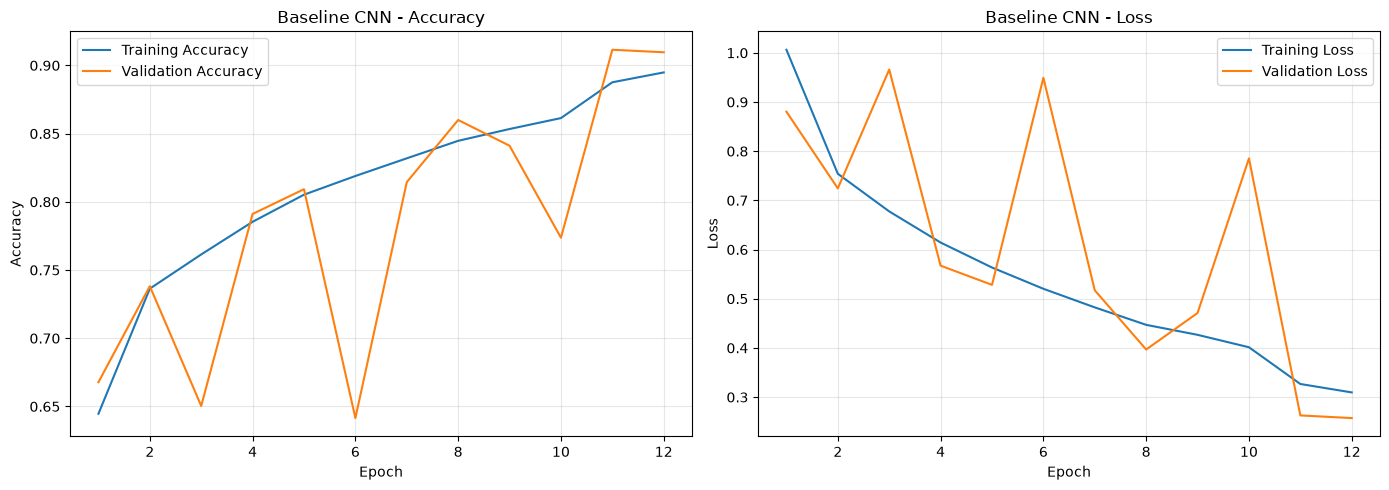

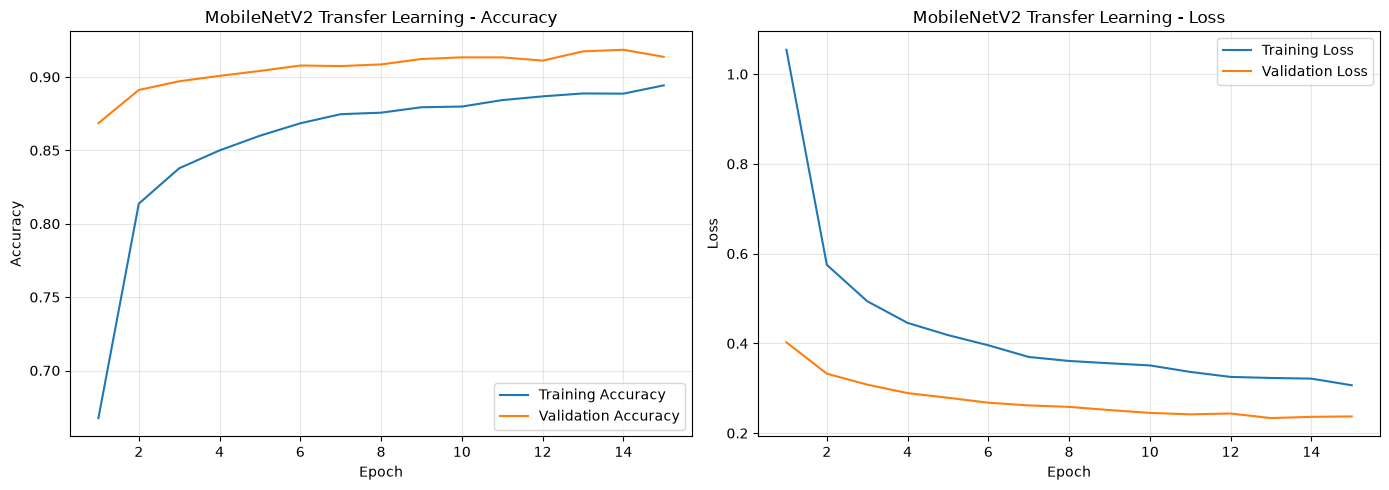

In [15]:
def plot_training_history(history: tf.keras.callbacks.History, title: str) -> None:
    history_df = pd.DataFrame(history.history)
    epochs = range(1, len(history_df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history_df["accuracy"], label="Training Accuracy")
    axes[0].plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history_df["loss"], label="Training Loss")
    axes[1].plot(epochs, history_df["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(baseline_history, "Baseline CNN")
plot_training_history(transfer_history, "MobileNetV2 Transfer Learning")

### Analisis Singkat Training

Cell berikut merangkum best validation accuracy, validation loss terbaik, dan gap train-validation. Pemilihan kandidat untuk fase evaluasi berikutnya hanya berdasarkan validation set, bukan test set.

In [16]:
def summarize_history(history: tf.keras.callbacks.History, model_name: str) -> dict:
    history_df = pd.DataFrame(history.history)
    best_epoch_index = int(history_df["val_accuracy"].idxmax())
    best_row = history_df.loc[best_epoch_index]
    accuracy_gap = float(best_row["accuracy"] - best_row["val_accuracy"])

    if accuracy_gap > 0.10:
        fit_status = "possible_overfitting"
    elif float(best_row["val_accuracy"]) < 0.75 and float(best_row["accuracy"]) < 0.80:
        fit_status = "possible_underfitting"
    else:
        fit_status = "reasonable_fit"

    return {
        "model_name": model_name,
        "best_epoch": best_epoch_index + 1,
        "best_train_accuracy": float(best_row["accuracy"]),
        "best_validation_accuracy": float(best_row["val_accuracy"]),
        "best_validation_loss": float(best_row["val_loss"]),
        "train_validation_accuracy_gap": accuracy_gap,
        "fit_status": fit_status,
    }


training_diagnostics_df = pd.DataFrame(
    [
        summarize_history(baseline_history, "baseline_cnn"),
        summarize_history(transfer_history, "mobilenetv2_transfer_learning"),
    ]
).sort_values("best_validation_accuracy", ascending=False)

selected_model_name = training_diagnostics_df.iloc[0]["model_name"]
selected_model = {
    "baseline_cnn": baseline_model,
    "mobilenetv2_transfer_learning": transfer_model,
}[selected_model_name]

selected_history = {
    "baseline_cnn": baseline_history,
    "mobilenetv2_transfer_learning": transfer_history,
}[selected_model_name]

training_diagnostics_df.to_csv(HISTORY_DIR / "training_diagnostics.csv", index=False)

print(f"Model kandidat untuk fase 04: {selected_model_name}")
print("Fine-tuning dapat dipertimbangkan jika validation accuracy masih rendah atau gap train-validation terlalu besar.")
training_diagnostics_df

Model kandidat untuk fase 04: mobilenetv2_transfer_learning
Fine-tuning dapat dipertimbangkan jika validation accuracy masih rendah atau gap train-validation terlalu besar.


,model_name,best_epoch,best_train_accuracy,best_validation_accuracy,best_validation_loss,train_validation_accuracy_gap,fit_status
1,mobilenetv2_transfer_learning,14,0.888611,0.918519,0.236357,-0.029907,reasonable_fit
0,baseline_cnn,11,0.887639,0.911481,0.262829,-0.023843,reasonable_fit


**Catatan fase 03:** model kandidat untuk fase evaluasi dipilih dari validation performance. Test set belum digunakan sama sekali untuk training, tuning, callback, atau pemilihan model. Fine-tuning MobileNetV2 dapat dilakukan pada iterasi berikutnya jika diagnostics menunjukkan underfitting atau validation accuracy belum memadai.

## Evaluasi dan Visualisasi

## Konversi Model

## Inference (Optional)